In [2]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import torch
import numpy as np
import cv2

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0422 19:35:29.332000 16368 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
import cv2
from PIL import Image

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("❌ Camera not detected")
else:
    print("✅ Camera opened")

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("❌ Failed to grab frame")
        break

    cv2.imshow("Live Feed", frame)

    # press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

✅ Camera opened
❌ Failed to grab frame


In [6]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)

model.eval()

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [7]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [ ]:
import cv2
from PIL import Image
import torch
import numpy as np

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("❌ Camera not detected")
else:
    print("✅ Camera opened")

ret, frame = cap.read()

if not ret:
    print("❌ Failed to grab frame")
else:
    print("✅ Frame captured")

    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits

    upsampled_logits = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1],
        mode="bilinear",
        align_corners=False
    )

    pred_seg = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

    print("Segmentation done")

    # visualization
    num_classes = model.config.num_labels
    colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)

    color_mask = colors[pred_seg]

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(frame_rgb, 0.6, color_mask, 0.4, 0)

    cv2.imshow("Segmentation", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.waitKey(0)
    cv2.destroyAllWindows()

cap.release()

✅ Camera opened
✅ Frame captured
✅ Segmentation done


In [ ]:
import cv2
import torch
import numpy as np
from PIL import Image



cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("❌ Camera not detected")
    exit()

print("✅ Camera opened")

frame_count = 0
last_pred = None

num_classes = model.config.num_labels
colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)


while True:

    ret, frame = cap.read()
    if not ret:
        break

    display_frame = cv2.resize(frame, (384, 384))

    frame_count += 1

    if frame_count % 3 == 0:

        input_frame = cv2.resize(frame, (384, 384))
        image = Image.fromarray(cv2.cvtColor(input_frame, cv2.COLOR_BGR2RGB))

        img = np.array(image).astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        img = (img - mean) / std

        img = img.transpose(2, 0, 1)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(model.device)

        with torch.no_grad():
            outputs = model(pixel_values=img)

        logits = outputs.logits

        pred_seg = logits.argmax(dim=1)[0].cpu().numpy()

        if last_pred is not None:
            pred_seg = (0.7 * last_pred + 0.3 * pred_seg).astype(np.uint8)

        last_pred = pred_seg

    else:
        if last_pred is None:
            cv2.imshow("Segmentation", display_frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            continue

        pred_seg = last_pred



    pred_seg = cv2.resize(
        pred_seg.astype(np.uint8),
        (display_frame.shape[1], display_frame.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )


    color_mask = colors[pred_seg]
    overlay = cv2.addWeighted(display_frame, 0.6, color_mask, 0.4, 0)

    cv2.imshow("Optimized Segmentation", overlay)


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()

✅ Camera opened


In [ ]:

ROAD = 0
SIDEWALK = 1

walkable_mask = (pred_seg == ROAD) | (pred_seg == SIDEWALK)

walkable_mask = walkable_mask.astype(np.uint8)

In [ ]:
import cv2
import torch
import numpy as np
from PIL import Image


cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

if not cap.isOpened():
    print("❌ Camera not detected")
    exit()

print("✅ Camera opened")


frame_count = 0
last_pred = None

num_classes = model.config.num_labels
colors = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)

ROAD = 0
SIDEWALK = 1


while True:

    ret, frame = cap.read()
    if not ret:
        break

    display_frame = cv2.resize(frame, (384, 384))
    frame_count += 1

    if frame_count % 3 == 0:

        input_frame = cv2.resize(frame, (384, 384))
        image = Image.fromarray(cv2.cvtColor(input_frame, cv2.COLOR_BGR2RGB))

        img = np.array(image).astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        img = (img - mean) / std

        img = img.transpose(2, 0, 1)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(model.device)

        with torch.no_grad():
            outputs = model(pixel_values=img)

        logits = outputs.logits
        pred_seg = logits.argmax(dim=1)[0].cpu().numpy()

        if last_pred is not None:
            pred_seg = (0.7 * last_pred + 0.3 * pred_seg).astype(np.uint8)

        last_pred = pred_seg

    else:
        if last_pred is None:
            cv2.imshow("Navigation AI", display_frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            continue

        pred_seg = last_pred

    pred_seg = cv2.resize(
        pred_seg.astype(np.uint8),
        (display_frame.shape[1], display_frame.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )


    walkable_mask = np.isin(pred_seg, [ROAD, SIDEWALK])

    h, w = walkable_mask.shape

    bottom = walkable_mask[h//2:, :]

    left_area = bottom[:, :w//2].sum()
    right_area = bottom[:, w//2:].sum()

    if left_area > right_area:
        direction = "LEFT"
    else:
        direction = "RIGHT"

    walkable_vis = display_frame.copy()
    walkable_vis[walkable_mask] = [0, 255, 0]

    overlay = cv2.addWeighted(display_frame, 0.7, walkable_vis, 0.3, 0)

    cv2.putText(
        overlay,
        f"Go {direction}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    cv2.imshow("Navigation AI", overlay)


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cap.release()
cv2.destroyAllWindows()

✅ Camera opened


In [ ]:
import os
import cv2
import numpy as np

image_dir = "pothole/Pothole_Segmentation_YOLOv8/train/images"
label_dir = "pothole/Pothole_Segmentation_YOLOv8/train/labels"
mask_dir = "pothole/Pothole_Segmentation_YOLOv8/train/masks"

os.makedirs(mask_dir, exist_ok=True)

for file in os.listdir(image_dir):

    img_path = os.path.join(image_dir, file)
    label_path = os.path.join(label_dir, file.replace(".jpg", ".txt"))
    mask_path = os.path.join(mask_dir, file.replace(".jpg", ".png"))

    image = cv2.imread(img_path)
    h, w = image.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)

    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            values = list(map(float, line.strip().split()))

            cls = int(values[0])
            polygon = values[1:]

            # convert normalized → pixel coords
            pts = []
            for i in range(0, len(polygon), 2):
                x = int(polygon[i] * w)
                y = int(polygon[i+1] * h)
                pts.append([x, y])

            pts = np.array(pts, dtype=np.int32)

            cv2.fillPoly(mask, [pts], 1)

    cv2.imwrite(mask_path, mask * 255)

print(" Polygon masks created")

✅ Polygon masks created


In [2]:
from datasets import Dataset
import os

train_img_dir = "pothole/Pothole_Segmentation_YOLOv8/train/images"
train_mask_dir = "pothole/Pothole_Segmentation_YOLOv8/train/masks"

valid_img_dir = "pothole/Pothole_Segmentation_YOLOv8/valid/images"
valid_mask_dir = "pothole/Pothole_Segmentation_YOLOv8/valid/masks"


def load_data(img_dir, mask_dir):
    images = []
    masks = []

    for file in os.listdir(img_dir):
        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file.replace(".jpg", ".png"))

        if os.path.exists(mask_path):
            images.append(img_path)
            masks.append(mask_path)

    return Dataset.from_dict({
        "image": images,
        "mask": masks
    })


train_dataset = load_data(train_img_dir, train_mask_dir)
valid_dataset = load_data(valid_img_dir, valid_mask_dir)

print(train_dataset)
print(valid_dataset)

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['image', 'mask'],
    num_rows: 720
})
Dataset({
    features: ['image', 'mask'],
    num_rows: 0
})


In [3]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]

In [14]:
from PIL import Image
import numpy as np

def preprocess(example):

    image = Image.open(example["image"]).convert("RGB")
    mask = Image.open(example["mask"])

    mask = np.array(mask)
    mask = (mask > 0).astype(np.int64)

    inputs = processor(
        images=image,
        segmentation_maps=mask,
        return_tensors="pt"
    )

    return {
        "pixel_values": inputs["pixel_values"][0],
        "labels": inputs["labels"][0]
    }

In [4]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class PotholeDataset(Dataset):
    def __init__(self, hf_dataset, processor):
        self.dataset = hf_dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]

        image = Image.open(example["image"]).convert("RGB")
        mask = Image.open(example["mask"])

        mask = np.array(mask)
        mask = (mask > 0).astype(np.int64)

        inputs = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt"
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "labels": inputs["labels"].squeeze(0)
        }

In [5]:
train_dataset = PotholeDataset(train_dataset, processor)
valid_dataset = PotholeDataset(valid_dataset, processor)

In [10]:
from transformers import TrainingArguments

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

training_args = TrainingArguments(
    output_dir="./pothole_model",
    learning_rate=5e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    save_strategy="epoch",
    logging_dir="./logs",
    fp16=True,

    evaluation_strategy="no",   # 🔥 FIX
)

In [11]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
)
trainer.train()

                                                 
 20%|██        | 180/900 [19:33<12:10,  1.01s/it]

{'loss': 0.0062, 'learning_rate': 2.2277777777777778e-05, 'epoch': 2.78}


                                                 
100%|██████████| 900/900 [15:58<00:00,  1.07s/it]

{'train_runtime': 958.7301, 'train_samples_per_second': 3.755, 'train_steps_per_second': 0.939, 'train_loss': 0.0037984765569368997, 'epoch': 5.0}


TrainOutput(global_step=900, training_loss=0.0037984765569368997, metrics={'train_runtime': 958.7301, 'train_samples_per_second': 3.755, 'train_steps_per_second': 0.939, 'train_loss': 0.0037984765569368997, 'epoch': 5.0})

In [13]:
trainer.save_model("pothole_model_final")

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.5.1+cu121
12.1


In [16]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

model = SegformerForSemanticSegmentation.from_pretrained(
    "pothole_model_final"
)
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

model.to("cuda")
model.eval()

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [27]:
import cv2
import torch
import numpy as np
from PIL import Image

img_path ="pottest.jpg" 

image = Image.open(img_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

pred = logits.argmax(dim=1)[0].cpu().numpy()

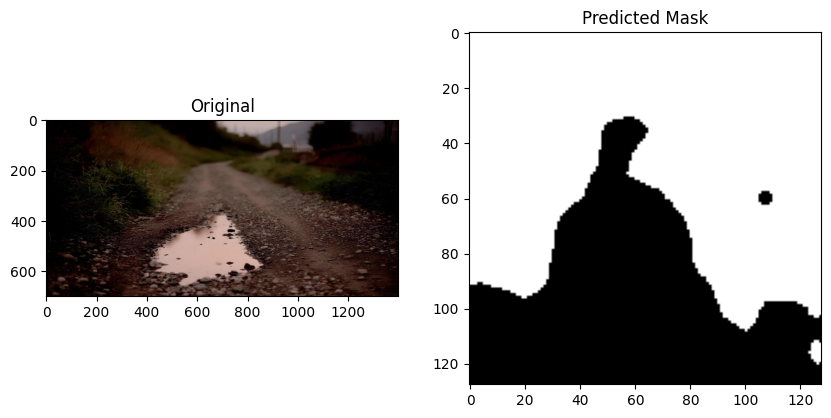

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(pred, cmap="gray")

plt.show()

In [1]:
import cv2
import torch
import numpy as np
from PIL import Image
from ultralytics import YOLO
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

# ------------------------------
# DEVICE
# ------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------
# MODELS
# ------------------------------

# YOLO
yolo = YOLO("yolov8n.pt")

# ROAD SEGMENTATION
road_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)
road_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
).to(device)

# POTHOLE MODEL (CHANGE PATH)
pothole_model = SegformerForSemanticSegmentation.from_pretrained(
    "pothole_model/checkpoint-900"   # 🔥 CHANGE THIS
).to(device)

pothole_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

# DEPTH MODEL
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device)
midas.eval()
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ------------------------------
# CAMERA
# ------------------------------
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # ------------------------------
    # YOLO
    # ------------------------------
    results = yolo(frame)
    annotated = results[0].plot()
    boxes = results[0].boxes

    obstacle_detected = False
    obstacle_name = ""

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cx = (x1 + x2) // 2

        if 250 < cx < 390:
            obstacle_detected = True
            obstacle_name = yolo.names[int(box.cls)]

    # ------------------------------
    # DEPTH
    # ------------------------------
    depth_input = midas_transform(rgb).to(device)

    with torch.no_grad():
        depth = midas(depth_input)
        depth = torch.nn.functional.interpolate(
            depth.unsqueeze(1),
            size=frame.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy()

    depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
    center_depth = depth_norm[200:300, 250:390].mean()

    # ------------------------------
    # ROAD SEGMENTATION
    # ------------------------------
    inputs = road_processor(images=rgb, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = road_model(**inputs)

    road_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()
    road_mask = cv2.resize(road_mask.astype(np.uint8), (640, 480))

    walkable = (road_mask == 0) | (road_mask == 1)

    center_walkable = walkable[200:300, 250:390]
    walkable_ratio = np.mean(center_walkable)

    # ------------------------------
    # POTHOLE DETECTION
    # ------------------------------
    inputs = pothole_processor(images=rgb, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = pothole_model(**inputs)

    pothole_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()
    pothole_mask = pothole_mask.astype(np.uint8)
    pothole_mask = cv2.resize(pothole_mask, (640, 480))

    pothole_mask = cv2.medianBlur(pothole_mask, 5)

    center_region = pothole_mask[200:300, 250:390]
    pothole_ratio = np.sum(center_region == 1) / center_region.size

    pothole_detected = pothole_ratio > 0.08

    # depth filter (avoid object confusion)
    if pothole_detected and center_depth < 0.3:
        pothole_detected = False

    # ------------------------------
    # WALL DETECTION (FIXED)
    # ------------------------------
    wall_detected = (center_depth < 0.3) and (walkable_ratio < 0.3)

    # ------------------------------
    # DECISION
    # ------------------------------
    message = "Path clear"

    if wall_detected:
        message = "Wall ahead. Stop"

    elif obstacle_detected:
        message = f"{obstacle_name} ahead"

    elif pothole_detected:
        message = "Pothole ahead. Avoid"

    # ------------------------------
    # VISUAL
    # ------------------------------
    overlay = annotated.copy()

    overlay[pothole_mask == 1] = (0, 0, 255)   # pothole = red
    overlay[walkable] = (0, 255, 0)            # path = green

    final = cv2.addWeighted(annotated, 0.7, overlay, 0.3, 0)

    cv2.putText(final, message, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 3)

    cv2.imshow("Assistive Navigation AI", final)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be re

Loading weights:  None


Using cache found in C:\Users\TVM2/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\TVM2/.cache\torch\hub\intel-isl_MiDaS_master



0: 480x640 1 person, 1 wine glass, 103.7ms
Speed: 190.9ms preprocess, 103.7ms inference, 30.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 22.8ms
Speed: 3.2ms preprocess, 22.8ms inference, 5.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 4 persons, 20.1ms
Speed: 2.8ms preprocess, 20.1ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 21.2ms
Speed: 2.4ms preprocess, 21.2ms inference, 4.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 26.2ms
Speed: 2.4ms preprocess, 26.2ms inference, 3.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 17.9ms
Speed: 2.8ms preprocess, 17.9ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 16.1ms
Speed: 1.8ms preprocess, 16.1ms inference, 3.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 3 persons, 17.5ms
Speed: 2.2ms preprocess, 17.5ms inference, 3.7ms postprocess pe

In [35]:
import os
print(os.listdir("pothole_model_final"))

['config.json', 'model.safetensors', 'training_args.bin']


C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(
Using cache found in C:\Users\TVM2/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\TVM2/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Using cache found in C:\Users\TVM2/.cache\torch\hub\intel-isl_MiDaS_master


0: 480x640 5 persons, 1 car, 69.2ms
Speed: 4.2ms preprocess, 69.2ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)
Decision: Path clear


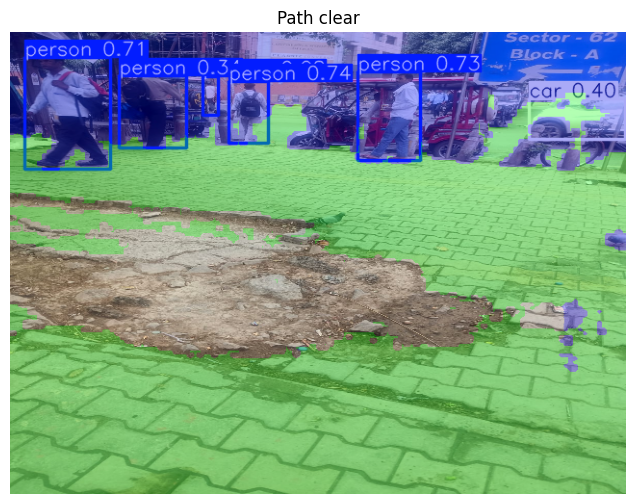

In [2]:
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

# ------------------------------
# DEVICE
# ------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------
# LOAD MODELS
# ------------------------------
yolo = YOLO("yolov8n.pt")

road_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)
road_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
).to(device)

pothole_model = SegformerForSemanticSegmentation.from_pretrained(
    "pothole_model/checkpoint-900"   # your saved model
).to(device)

pothole_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small").to(device)
midas.eval()
midas_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# ------------------------------
# LOAD IMAGE
# ------------------------------
img_path = "jiit1.jpeg"   # 🔥 CHANGE THIS

image = cv2.imread(img_path)
image = cv2.resize(image, (640, 480))
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# ------------------------------
# YOLO
# ------------------------------
results = yolo(image)
annotated = results[0].plot()
boxes = results[0].boxes

obstacle_detected = False
obstacle_name = ""

for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cx = (x1 + x2) // 2

    if 250 < cx < 390:
        obstacle_detected = True
        obstacle_name = yolo.names[int(box.cls)]

# ------------------------------
# DEPTH
# ------------------------------
depth_input = midas_transform(rgb).to(device)

with torch.no_grad():
    depth = midas(depth_input)
    depth = torch.nn.functional.interpolate(
        depth.unsqueeze(1),
        size=rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu().numpy()

depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
center_depth = depth_norm[200:300, 250:390].mean()

# ------------------------------
# ROAD SEGMENTATION
# ------------------------------
inputs = road_processor(images=rgb, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = road_model(**inputs)

road_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()
road_mask = cv2.resize(road_mask.astype(np.uint8), (640, 480))

walkable = (road_mask == 0) | (road_mask == 1)

center_walkable = walkable[200:300, 250:390]
walkable_ratio = np.mean(center_walkable)

# ------------------------------
# POTHOLE DETECTION
# ------------------------------
inputs = pothole_processor(images=rgb, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = pothole_model(**inputs)

pothole_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()
pothole_mask = pothole_mask.astype(np.uint8)
pothole_mask = cv2.resize(pothole_mask, (640, 480))
pothole_mask = cv2.medianBlur(pothole_mask, 5)

center_region = pothole_mask[200:300, 250:390]
pothole_ratio = np.sum(center_region == 1) / center_region.size

pothole_detected = pothole_ratio > 0.08

if pothole_detected and center_depth < 0.3:
    pothole_detected = False

# ------------------------------
# WALL DETECTION
# ------------------------------
wall_detected = (center_depth < 0.3) and (walkable_ratio < 0.3)

# ------------------------------
# DECISION
# ------------------------------
message = "Path clear"

if wall_detected:
    message = "Wall ahead. Stop"

elif obstacle_detected:
    message = f"{obstacle_name} ahead"

elif pothole_detected:
    message = "Pothole ahead. Avoid"

print("Decision:", message)

# ------------------------------
# VISUALIZATION
# ------------------------------
overlay = annotated.copy()

overlay[pothole_mask == 1] = (255, 0, 0)
overlay[walkable] = (0, 255, 0)

final = cv2.addWeighted(annotated, 0.7, overlay, 0.3, 0)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.title(message)
plt.axis("off")
plt.show()

In [11]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# load processor
processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512"
)

# load YOUR trained model
model = SegformerForSemanticSegmentation.from_pretrained(
    "pothole_model/checkpoint-900"
).to(device)

# NOW this works
model.eval()

C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\TVM2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

In [ ]:
import os
import cv2
import numpy as np

img_dir = "pothole/Pothole_Segmentation_YOLOv8/valid/images"
label_dir = "pothole/Pothole_Segmentation_YOLOv8/valid/labels"
mask_dir = "pothole/Pothole_Segmentation_YOLOv8/valid/masks"

os.makedirs(mask_dir, exist_ok=True)

for file in os.listdir(img_dir):

    img_path = os.path.join(img_dir, file)
    label_path = os.path.join(label_dir, file.replace(".jpg", ".txt"))

    if not os.path.exists(label_path):
        continue

    image = cv2.imread(img_path)
    h, w, _ = image.shape

    mask = np.zeros((h, w), dtype=np.uint8)

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = list(map(float, line.strip().split()))

        cls = int(parts[0])
        coords = parts[1:]

        if len(coords) >= 6:
            points = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i+1] * h)
                points.append([x, y])

            points = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [points], 255)

        # fallback (bbox)
        else:
            xc, yc, bw, bh = coords
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            cv2.rectangle(mask, (x1, y1), (x2, y2), 255, -1)

    cv2.imwrite(os.path.join(mask_dir, file.replace(".jpg", ".png")), mask)

print("✅ FIXED: masks created correctly")

✅ FIXED: masks created correctly


In [19]:
mask = cv2.imread(mask_path, 0)
print(np.unique(mask))

[  0 255]


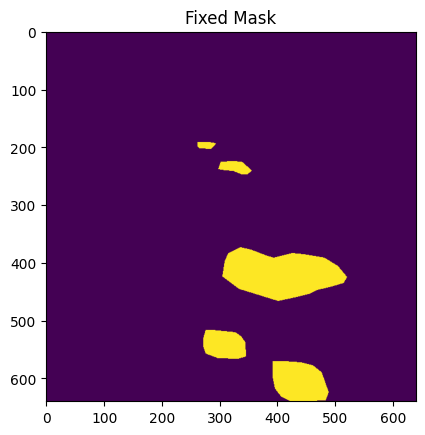

In [20]:
import matplotlib.pyplot as plt
plt.imshow(mask)
plt.title("Fixed Mask")
plt.show()

In [21]:
import os
import cv2
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ------------------------------
# STORAGE
# ------------------------------
y_true = []
y_pred = []

# ------------------------------
# LOOP
# ------------------------------
for file in tqdm(image_files):
    print("GT labels count:", np.unique(y_true, return_counts=True))
    print("Pred labels count:", np.unique(y_pred, return_counts=True))
    img_path = os.path.join(img_dir, file)
    mask_path = os.path.join(mask_dir, file.replace(".jpg", ".png"))

    if not os.path.exists(mask_path):
        continue

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, 0)
    mask = (mask > 0).astype(np.uint8)

    # ground truth: does pothole exist?
    gt_label = 1 if np.sum(mask) > 100 else 0

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = outputs.logits.argmax(dim=1)[0].cpu().numpy()

    # prediction: does pothole exist?
    pred_label = 1 if np.sum(pred == 1) > 100 else 0

    y_true.append(gt_label)
    y_pred.append(pred_label)

# ------------------------------
# METRICS
# ------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n📊 REGION-LEVEL RESULTS")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

  0%|          | 0/60 [00:00<?, ?it/s]

GT labels count: (array([], dtype=float64), array([], dtype=int64))
Pred labels count: (array([], dtype=float64), array([], dtype=int64))


  3%|▎         | 2/60 [00:00<00:11,  5.05it/s]

GT labels count: (array([1]), array([1], dtype=int64))
Pred labels count: (array([1]), array([1], dtype=int64))
GT labels count: (array([1]), array([2], dtype=int64))
Pred labels count: (array([1]), array([2], dtype=int64))
GT labels count: (array([1]), array([3], dtype=int64))
Pred labels count: (array([1]), array([3], dtype=int64))


 10%|█         | 6/60 [00:00<00:04, 10.81it/s]

...

GT labels count: (array([1]), array([52], dtype=int64))
Pred labels count: (array([1]), array([52], dtype=int64))
GT labels count: (array([1]), array([53], dtype=int64))
Pred labels count: (array([1]), array([53], dtype=int64))
GT labels count: (array([1]), array([54], dtype=int64))
Pred labels count: (array([1]), array([54], dtype=int64))


 93%|█████████▎| 56/60 [00:04<00:00, 12.61it/s]

GT labels count: (array([1]), array([55], dtype=int64))
Pred labels count: (array([1]), array([55], dtype=int64))
GT labels count: (array([1]), array([56], dtype=int64))
Pred labels count: (array([1]), array([56], dtype=int64))
GT labels count: (array([1]), array([57], dtype=int64))
Pred labels count: (array([1]), array([57], dtype=int64))


100%|██████████| 60/60 [00:04<00:00, 12.15it/s]

GT labels count: (array([1]), array([58], dtype=int64))
Pred labels count: (array([1]), array([58], dtype=int64))
GT labels count: (array([1]), array([59], dtype=int64))
Pred labels count: (array([1]), array([59], dtype=int64))

📊 REGION-LEVEL RESULTS
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [11]:
print("GT sum:", np.sum(mask))
print("Pred sum:", np.sum(pred == 1))
print("GT label:", gt_label)
print("Pred label:", pred_label)
print("----")
break

GT sum: 0
Pred sum: 7830
GT label: 0
Pred label: 1
----


SyntaxError: 'break' outside loop (1789647191.py, line 6)